In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.model_selection as train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [39]:
import os
print(os.path.exists(r"C:\Users\Akash\Downloads"))

True


In [40]:
df = pd.read_excel(r'C:\Users\Akash\Downloads\Housing.xlsx')

In [41]:
df.head()

,area,bedrooms,bathrooms,stories,parking,price
0,1500,3,2,1,1,4500000
1,1700,3,2,2,1,5200000
2,1800,4,3,2,2,6000000
3,1200,2,1,1,1,3500000
4,2000,4,3,2,2,6800000


In [42]:
df.tail()

,area,bedrooms,bathrooms,stories,parking,price
15,1100,2,1,1,0,3200000
16,2400,4,4,2,2,8200000
17,2600,5,4,3,3,9000000
18,1450,3,2,1,1,4300000
19,1850,4,3,2,2,6100000


In [43]:
df.shape

(20, 6)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   area       20 non-null     int64
 1   bedrooms   20 non-null     int64
 2   bathrooms  20 non-null     int64
 3   stories    20 non-null     int64
 4   parking    20 non-null     int64
 5   price      20 non-null     int64
dtypes: int64(6)
memory usage: 1.1 KB


In [45]:
df.describe()


,area,bedrooms,bathrooms,stories,parking,price
count,20.000000,20.000000,20.000000,20.00000,20.000000,2.000000e+01
mean,1910.000000,3.600000,2.800000,1.85000,1.750000,6.245000e+06
std,539.395373,0.994723,1.105013,0.67082,0.850696,2.127137e+06
min,1100.000000,2.000000,1.000000,1.00000,0.000000,3.200000e+06
25%,1487.500000,3.000000,2.000000,1.00000,1.000000,4.450000e+06
50%,1825.000000,4.000000,3.000000,2.00000,2.000000,6.050000e+06
75%,2250.000000,4.000000,4.000000,2.00000,2.000000,7.750000e+06
max,3000.000000,5.000000,5.000000,3.00000,3.000000,1.050000e+07


In [46]:
df.isnull().sum()

area         0
bedrooms     0
bathrooms    0
stories      0
parking      0
price        0
dtype: int64

In [47]:
#If there are any missing values fill them or remove them
df.fillna(df.mean(), inplace=True)

In [48]:
# EDA

<Axes: xlabel='area', ylabel='price'>

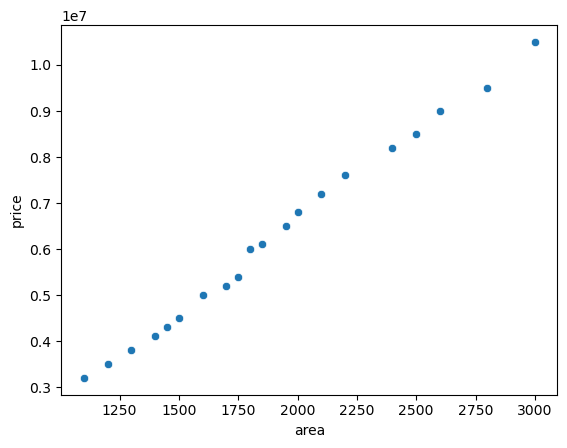

In [49]:
#RELATIONSHIP BW X AND Y
sns.scatterplot(x='area', y='price', data=df)

<Axes: xlabel='price', ylabel='Count'>

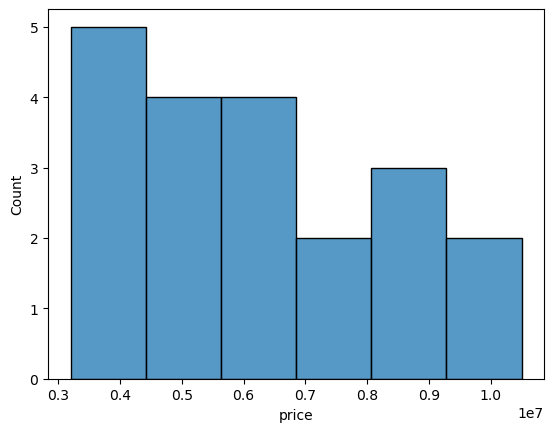

In [50]:
#SHOWS PRICE DISTRIBUTION
sns.histplot(df['price'])

<Axes: >

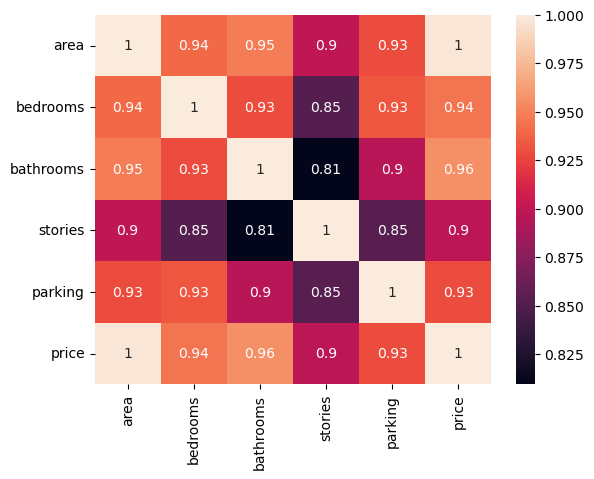

In [51]:
#SHOWS CORELATION
sns.heatmap(df.corr(), annot=True)
#annot is basically the annotation
# dark red = strong =ve correlatiyion = +1
# white = weak correlation = 0
# blue = negative correlation = -1

In [52]:
X = df[['area','bedrooms','bathrooms']]

In [59]:
from sklearn.model_selection import train_test_split

X = df[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [60]:
print(X.head())
print(y.head())

   area  bedrooms  bathrooms  stories  parking
0  1500         3          2        1        1
1  1700         3          2        2        1
2  1800         4          3        2        2
3  1200         2          1        1        1
4  2000         4          3        2        2
0    4500000
1    5200000
2    6000000
3    3500000
4    6800000
Name: price, dtype: int64


In [62]:
from sklearn.linear_model import LinearRegression

In [63]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [64]:
y_pred = model.predict(X_test)

In [65]:
print(y_pred)

[4618967.38618146 8983016.7782073  3041363.46498241 5395784.23979635]


In [66]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

In [67]:
print(comparison)

     Actual     Predicted
0   4500000  4.618967e+06
17  9000000  8.983017e+06
15  3200000  3.041363e+06
1   5200000  5.395784e+06


In [72]:
#Mean squared error
mse = mean_absolute_error(y_test, y_pred)
print(mse)

122592.84569702693


In [74]:
#root mean squared error
rmse = np.sqrt(mse)
print(rmse)

350.1326115874197


In [76]:
# r square sore
r2 = r2_score(y_test, y_pred)
print(r2)

0.9958159340978482


In [80]:
#preditcing the price of the house
new_house = pd.DataFrame({
    'area': [2300],
    'bedrooms': [4],
    'bathrooms': [3],
    'stories': [2],
    'parking': [2]
})

predicted_price = model.predict(new_house)

print(predicted_price)


[7662972.47619952]
